In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

print("All libraries imported successfully.")

All libraries imported successfully.


In [17]:
# Load the California Housing Dataset
housing = fetch_california_housing()

# Convert to DataFrame for easier handling
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target   # Target: Median House Value (in $100,000s)

print("Dataset Shape:", df.shape)
print("\nFeature Names:", housing.feature_names)
print("\nTarget: MedHouseVal (Median House Value in $100,000s)")
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (20640, 9)

Feature Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: MedHouseVal (Median House Value in $100,000s)

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.32520000,41.00000000,6.98412698,1.02380952,322.00000000,2.55555556,37.88000000,-122.23000000,4.52600000
1,8.30140000,21.00000000,6.23813708,0.97188049,2401.00000000,2.10984183,37.86000000,-122.22000000,3.58500000
2,7.25740000,52.00000000,8.28813559,1.07344633,496.00000000,2.80225989,37.85000000,-122.24000000,3.52100000
3,5.64310000,52.00000000,5.81735160,1.07305936,558.00000000,2.54794521,37.85000000,-122.25000000,3.41300000
4,3.84620000,52.00000000,6.28185328,1.08108108,565.00000000,2.18146718,37.85000000,-122.25000000,3.42200000


In [18]:
# Basic dataset statistics
print("Dataset Statistics:")
df.describe()

Dataset Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00000000,20640.00000000,20640.00000000,20640.00000000,20640.00000000,20640.00000000,20640.00000000,20640.00000000,20640.00000000
mean,3.87067100,28.63948643,5.42899974,1.09667515,1425.47674419,3.07065516,35.63186143,-119.56970446,2.06855817
std,1.89982172,12.58555761,2.47417314,0.47391086,1132.46212177,10.38604956,2.13595240,2.00353172,1.15395616
min,0.49990000,1.00000000,0.84615385,0.33333333,3.00000000,0.69230769,32.54000000,-124.35000000,0.14999000
25%,2.56340000,18.00000000,4.44071624,1.00607905,787.00000000,2.42974115,33.93000000,-121.80000000,1.19600000
50%,3.53480000,29.00000000,5.22912879,1.04878049,1166.00000000,2.81811565,34.26000000,-118.49000000,1.79700000
75%,4.74325000,37.00000000,6.05238095,1.09952607,1725.00000000,3.28226092,37.71000000,-118.01000000,2.64725000
max,15.00010000,52.00000000,141.90909091,34.06666667,35682.00000000,1243.33333333,41.95000000,-114.31000000,5.00001000


In [19]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print("\nNo missing values — dataset is clean and ready.")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

No missing values — dataset is clean and ready.


In [20]:
# Select single feature and target
X_simple = df[['AveRooms']].values    # shape: (n, 1)
y = df['MedHouseVal'].values          # shape: (n,)

# Clip extreme outliers for cleaner visualization
mask = X_simple[:, 0] < 20
X_simple = X_simple[mask]
y_simple = y[mask]

print(f"Samples after clipping outliers: {X_simple.shape[0]}")
print(f"X_simple shape: {X_simple.shape}")
print(f"y_simple shape: {y_simple.shape}")

Samples after clipping outliers: 20571
X_simple shape: (20571, 1)
y_simple shape: (20571,)


In [21]:
def ols_linear_regression(X, y):
    """
    Compute OLS coefficients manually using the Normal Equation.
    
    Parameters:
        X : numpy array of shape (n_samples, n_features)
        y : numpy array of shape (n_samples,)
    
    Returns:
        intercept : float
        coefficients : numpy array
    """
    # Step 1: Add a bias column (column of ones) for the intercept
    n_samples = X.shape[0]
    X_b = np.column_stack([np.ones(n_samples), X])   # shape: (n, 1+features)

    # Step 2: Apply OLS Normal Equation: beta = (X^T X)^-1 X^T y
    beta = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

    # Step 3: Extract intercept (beta[0]) and slope(s) (beta[1:])
    intercept = beta[0]
    coefficients = beta[1:]

    return intercept, coefficients


def predict_manual(X, intercept, coefficients):
    """
    Predict target values using computed OLS coefficients.
    """
    return intercept + X @ coefficients


# Compute OLS for simple regression
manual_intercept_simple, manual_coef_simple = ols_linear_regression(X_simple, y_simple)

print("=== Manual OLS: Simple Linear Regression ===")
print(f"  Intercept (b0) : {manual_intercept_simple:.6f}")
print(f"  Coefficient (b1) for AveRooms: {manual_coef_simple[0]:.6f}")
print(f"\n  Equation: MedHouseVal = {manual_intercept_simple:.4f} + {manual_coef_simple[0]:.4f} * AveRooms")

=== Manual OLS: Simple Linear Regression ===
  Intercept (b0) : 0.882615
  Coefficient (b1) for AveRooms: 0.222522

  Equation: MedHouseVal = 0.8826 + 0.2225 * AveRooms


In [22]:
# Fit sklearn model on the same data
sklearn_model_simple = LinearRegression()
sklearn_model_simple.fit(X_simple, y_simple)

sklearn_intercept_simple = sklearn_model_simple.intercept_
sklearn_coef_simple = sklearn_model_simple.coef_

print("=== Sklearn: Simple Linear Regression ===")
print(f"  Intercept (b0) : {sklearn_intercept_simple:.6f}")
print(f"  Coefficient (b1) for AveRooms: {sklearn_coef_simple[0]:.6f}")
print(f"\n  Equation: MedHouseVal = {sklearn_intercept_simple:.4f} + {sklearn_coef_simple[0]:.4f} * AveRooms")

=== Sklearn: Simple Linear Regression ===
  Intercept (b0) : 0.882615
  Coefficient (b1) for AveRooms: 0.222522

  Equation: MedHouseVal = 0.8826 + 0.2225 * AveRooms


In [23]:
comparison_simple = pd.DataFrame({
    'Parameter'  : ['Intercept (b0)', 'Coefficient b1 (AveRooms)'],
    'Manual OLS' : [manual_intercept_simple, manual_coef_simple[0]],
    'Sklearn'    : [sklearn_intercept_simple, sklearn_coef_simple[0]],
})

comparison_simple['Difference'] = abs(comparison_simple['Manual OLS'] - comparison_simple['Sklearn'])

print("=== Simple Linear Regression — Manual vs Sklearn ===")
comparison_simple.round(8)

=== Simple Linear Regression — Manual vs Sklearn ===


,Parameter,Manual OLS,Sklearn,Difference
0,Intercept (b0),0.88261523,0.88261523,0.00000000
1,Coefficient b1 (AveRooms),0.22252245,0.22252245,0.00000000


> **Observation:** The difference between Manual OLS and Sklearn results should be extremely small (< 1e-8), confirming that the manual OLS formula is correctly implemented.

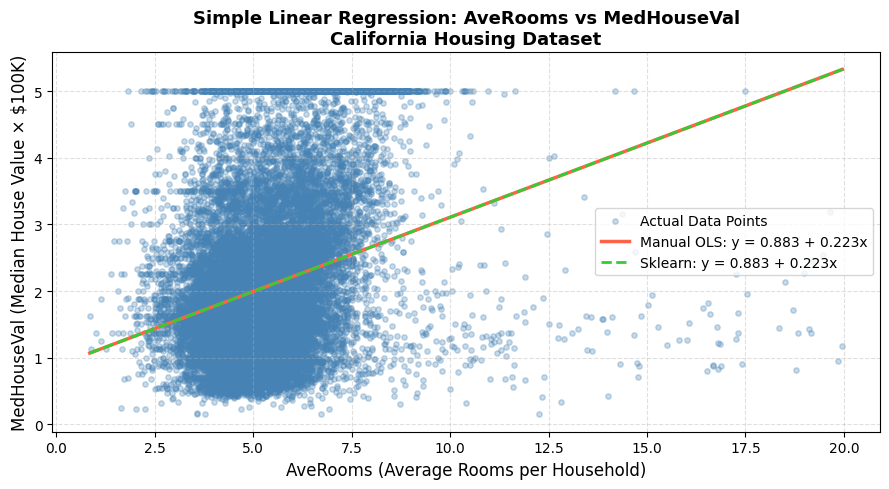

Plot saved as 'simple_regression_plot.png'


In [24]:
# Generate predictions from both models
x_line = np.linspace(X_simple.min(), X_simple.max(), 300).reshape(-1, 1)

y_line_manual  = predict_manual(x_line, manual_intercept_simple, manual_coef_simple)
y_line_sklearn = sklearn_model_simple.predict(x_line)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

# Scatter plot of actual data
ax.scatter(
    X_simple, y_simple,
    color='steelblue', alpha=0.3, s=15,
    label='Actual Data Points'
)

# Manual OLS regression line
ax.plot(
    x_line, y_line_manual,
    color='tomato', linewidth=2.5, linestyle='-',
    label=f'Manual OLS: y = {manual_intercept_simple:.3f} + {manual_coef_simple[0]:.3f}x'
)

# Sklearn regression line (dashed — overlaps manual, proving correctness)
ax.plot(
    x_line, y_line_sklearn,
    color='limegreen', linewidth=2, linestyle='--',
    label=f'Sklearn: y = {sklearn_intercept_simple:.3f} + {sklearn_coef_simple[0]:.3f}x'
)

ax.set_xlabel('AveRooms (Average Rooms per Household)', fontsize=12)
ax.set_ylabel('MedHouseVal (Median House Value × $100K)', fontsize=12)
ax.set_title('Simple Linear Regression: AveRooms vs MedHouseVal\nCalifornia Housing Dataset', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('simple_regression_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'simple_regression_plot.png'")

In [25]:
# Prepare full feature matrix and target
X_full = df[housing.feature_names].values   # shape: (20640, 8)
y_full = df['MedHouseVal'].values

print(f"X_full shape : {X_full.shape}")
print(f"y_full shape : {y_full.shape}")
print(f"Feature names: {housing.feature_names}")

X_full shape : (20640, 8)
y_full shape : (20640,)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [26]:
# Reusing the same ols_linear_regression function — it handles multiple features automatically
manual_intercept_multi, manual_coef_multi = ols_linear_regression(X_full, y_full)

print("=== Manual OLS: Multiple Linear Regression ===")
print(f"  Intercept (b0) : {manual_intercept_multi:.6f}")
print()
for name, coef in zip(housing.feature_names, manual_coef_multi):
    print(f"  b_{name:<12} : {coef:.6f}")

=== Manual OLS: Multiple Linear Regression ===
  Intercept (b0) : -36.941920

  b_MedInc       : 0.436693
  b_HouseAge     : 0.009436
  b_AveRooms     : -0.107322
  b_AveBedrms    : 0.645066
  b_Population   : -0.000004
  b_AveOccup     : -0.003787
  b_Latitude     : -0.421314
  b_Longitude    : -0.434514


In [27]:
sklearn_model_multi = LinearRegression()
sklearn_model_multi.fit(X_full, y_full)

sklearn_intercept_multi = sklearn_model_multi.intercept_
sklearn_coef_multi      = sklearn_model_multi.coef_

print("=== Sklearn: Multiple Linear Regression ===")
print(f"  Intercept (b0) : {sklearn_intercept_multi:.6f}")
print()
for name, coef in zip(housing.feature_names, sklearn_coef_multi):
    print(f"  b_{name:<12} : {coef:.6f}")

=== Sklearn: Multiple Linear Regression ===
  Intercept (b0) : -36.941920

  b_MedInc       : 0.436693
  b_HouseAge     : 0.009436
  b_AveRooms     : -0.107322
  b_AveBedrms    : 0.645066
  b_Population   : -0.000004
  b_AveOccup     : -0.003787
  b_Latitude     : -0.421314
  b_Longitude    : -0.434514


In [28]:
parameters   = ['Intercept (b0)'] + [f'b_{name}' for name in housing.feature_names]
manual_vals  = [manual_intercept_multi]  + list(manual_coef_multi)
sklearn_vals = [sklearn_intercept_multi] + list(sklearn_coef_multi)

comparison_multi = pd.DataFrame({
    'Parameter'  : parameters,
    'Manual OLS' : manual_vals,
    'Sklearn'    : sklearn_vals,
})

comparison_multi['Absolute Difference'] = abs(
    comparison_multi['Manual OLS'] - comparison_multi['Sklearn']
)

pd.set_option('display.float_format', '{:.8f}'.format)
pd.set_option('display.max_columns', 10)

print("=== Multiple Linear Regression — Manual OLS vs Sklearn ===")
comparison_multi

=== Multiple Linear Regression — Manual OLS vs Sklearn ===


,Parameter,Manual OLS,Sklearn,Absolute Difference
0,Intercept (b0),-36.94192021,-36.94192021,0.00000000
1,b_MedInc,0.43669329,0.43669329,0.00000000
2,b_HouseAge,0.00943578,0.00943578,0.00000000
3,b_AveRooms,-0.10732204,-0.10732204,0.00000000
4,b_AveBedrms,0.64506569,0.64506569,0.00000000
5,b_Population,-0.00000398,-0.00000398,0.00000000
6,b_AveOccup,-0.00378654,-0.00378654,0.00000000
7,b_Latitude,-0.42131438,-0.42131438,0.00000000
8,b_Longitude,-0.43451375,-0.43451375,0.00000000


> **Observation:** All absolute differences are effectively zero (floating-point precision level), confirming that the manual OLS formula produces identical results to sklearn's internal implementation.

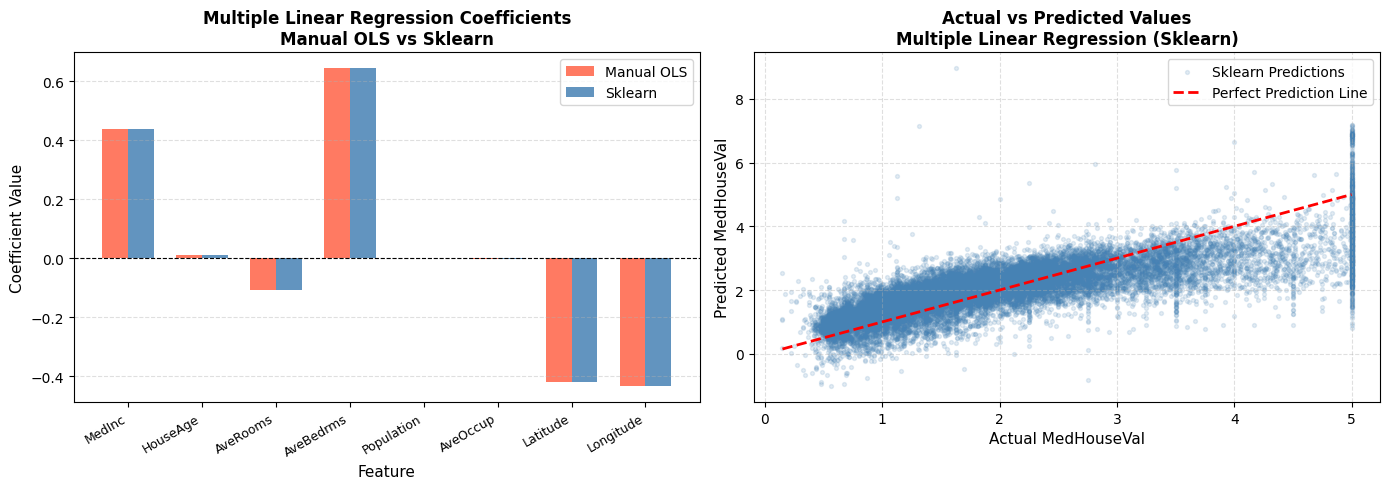

Plot saved as 'multiple_regression_analysis.png'


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feature_names = list(housing.feature_names)
x_pos = np.arange(len(feature_names))
bar_width = 0.35

# ---- Left plot: Coefficient comparison bar chart ----
ax = axes[0]
bars_manual  = ax.bar(x_pos - bar_width/2, manual_coef_multi,  bar_width, label='Manual OLS', color='tomato',   alpha=0.85)
bars_sklearn = ax.bar(x_pos + bar_width/2, sklearn_coef_multi, bar_width, label='Sklearn',    color='steelblue', alpha=0.85)

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Coefficient Value', fontsize=11)
ax.set_title('Multiple Linear Regression Coefficients\nManual OLS vs Sklearn', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=30, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

# ---- Right plot: Actual vs Predicted scatter plot ----
ax2 = axes[1]

y_pred_sklearn = sklearn_model_multi.predict(X_full)
y_pred_manual  = predict_manual(X_full, manual_intercept_multi, manual_coef_multi)

ax2.scatter(y_full, y_pred_sklearn, alpha=0.15, s=8, color='steelblue', label='Sklearn Predictions')
ax2.plot(
    [y_full.min(), y_full.max()],
    [y_full.min(), y_full.max()],
    color='red', linewidth=2, linestyle='--', label='Perfect Prediction Line'
)
ax2.set_xlabel('Actual MedHouseVal', fontsize=11)
ax2.set_ylabel('Predicted MedHouseVal', fontsize=11)
ax2.set_title('Actual vs Predicted Values\nMultiple Linear Regression (Sklearn)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('multiple_regression_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as 'multiple_regression_analysis.png'")

In [30]:
def compute_metrics(y_true, y_pred, model_name):
    """Compute and display regression evaluation metrics."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"  {'MSE':<6}: {mse:.4f}")
    print(f"  {'RMSE':<6}: {rmse:.4f}")
    print(f"  {'R2':<6}: {r2:.4f}")
    return {'Model': model_name, 'MSE': round(mse, 4), 'RMSE': round(rmse, 4), 'R2': round(r2, 4)}

print("========================================")
print(" SIMPLE LINEAR REGRESSION (AveRooms)")
print("========================================")

y_pred_simple_manual  = predict_manual(X_simple, manual_intercept_simple, manual_coef_simple)
y_pred_simple_sklearn = sklearn_model_simple.predict(X_simple)

print("\n--- Manual OLS ---")
m1 = compute_metrics(y_simple, y_pred_simple_manual, 'Simple - Manual OLS')

print("\n--- Sklearn ---")
m2 = compute_metrics(y_simple, y_pred_simple_sklearn, 'Simple - Sklearn')

print("\n========================================")
print(" MULTIPLE LINEAR REGRESSION (All Features)")
print("========================================")

print("\n--- Manual OLS ---")
m3 = compute_metrics(y_full, y_pred_manual, 'Multiple - Manual OLS')

print("\n--- Sklearn ---")
m4 = compute_metrics(y_full, y_pred_sklearn, 'Multiple - Sklearn')

print("\n========================================")
print(" SUMMARY TABLE")
print("========================================")
summary = pd.DataFrame([m1, m2, m3, m4])
summary

 SIMPLE LINEAR REGRESSION (AveRooms)

--- Manual OLS ---
  MSE   : 1.2328
  RMSE  : 1.1103
  R2    : 0.0751

--- Sklearn ---
  MSE   : 1.2328
  RMSE  : 1.1103
  R2    : 0.0751

 MULTIPLE LINEAR REGRESSION (All Features)

--- Manual OLS ---
  MSE   : 0.5243
  RMSE  : 0.7241
  R2    : 0.6062

--- Sklearn ---
  MSE   : 0.5243
  RMSE  : 0.7241
  R2    : 0.6062

 SUMMARY TABLE


,Model,MSE,RMSE,R2
0,Simple - Manual OLS,1.23280000,1.11030000,0.07510000
1,Simple - Sklearn,1.23280000,1.11030000,0.07510000
2,Multiple - Manual OLS,0.52430000,0.72410000,0.60620000
3,Multiple - Sklearn,0.52430000,0.72410000,0.60620000
